# Initial Imports and Constants

In [57]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from scipy.stats import norm
from scipy.optimize import curve_fit

In [58]:
tess_offset = 2457000

# Get Data

In [59]:
### Planet params 
per_2=  28.579889 #28.579743
rp_2= 0.0312382795966642 #0.03118
b_2=  0.482378819760311 #0.630
T14_2= 4.47016349523855 * 0.0416667    #4.162 * 0.0416667  # convert to days from hours 


In [60]:
# planet b
per_3=  38.352562 #38.353037
rp_3=  0.0305954481349672 #0.02916
b_3=  0.323085496752003 #0.440
T14_3= 5.51199861214238 * 0.0416667 #5.36 * 0.0416667  # convert to days from hours (from Gunther et al 2019)


In [61]:
df = pd.read_csv("toi_1339_transit_data_all.txt", sep="\s+", header=0, names=['Planet_num', 'Index', 'Tc', 'Tc_err'])

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_50128/2846524796.py:1: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv("toi_1339_transit_data_all.txt", sep="\s+", header=0, names=['Planet_num', 'Index', 'Tc', 'Tc_err'])


In [62]:
print(df)

    Planet_num  Index           Tc    Tc_err
0            2      0  1726.054975  0.001694
1            2      1  1754.634044  0.001688
2            2      2  1783.211479  0.001935
3            2      3  1811.799709  0.001910
4            2      4  1840.375325  0.001693
5            2      6  1897.534913  0.002112
6            2      7  1926.116113  0.001988
7            2     25  2440.545208  0.001594
8            2     32  2640.606858  0.001776
9            2     34  2697.771507  0.001340
10           2     35  2726.352900  0.001970
11           2     38  2812.096804  0.001729
12           2     39  2840.673083  0.001279
13           2     42  2926.419096  0.001672
14           2     55  3297.971035  0.001672
15           2     57  3355.129798  0.001043
16           2     58  3383.710605  0.001424
17           2     60  3440.876620  0.001650
18           2     64  3555.195637  0.001349
19           2     65  3583.771809  0.001702
20           2     66  3612.349687  0.001462
21        

In [63]:
indices_2 = df[df['Planet_num'] == 2]['Index'].tolist()
transit_times_2 = df[df['Planet_num'] == 2]['Tc'].tolist()
tc_err_2 = df[df['Planet_num'] == 2]['Tc_err'].tolist()

indices_3 = df[df['Planet_num'] == 3]['Index'].tolist()
transit_times_3 = df[df['Planet_num'] == 3]['Tc'].tolist()
tc_err_3 = df[df['Planet_num'] == 3]['Tc_err'].tolist()


# OMC

In [64]:
# Define linear ephemeris function
def linear_ephem(E, T0, P):
    return T0 + P * E

# Function to compute O-C per planet
def compute_oc(df):
    df_all = []
    fit_params = []  # store fit results here

    for planet in df['Planet_num'].unique():
        planet_df = df[df['Planet_num'] == planet].copy()
        E = planet_df['Index'].values
        Tc_obs = planet_df['Tc'].values
        Tc_err = planet_df['Tc_err'].values

        # Fit linear ephemeris
        popt, pcov = curve_fit(linear_ephem, E, Tc_obs, sigma=Tc_err, absolute_sigma=True)
        T0, P = popt
        T0_err, P_err = np.sqrt(np.diag(pcov))

        Tc_calc = linear_ephem(E, T0, P)
        oc = Tc_obs - Tc_calc

        planet_df['Tcalc'] = Tc_calc
        planet_df['O-C'] = oc
        planet_df['Planet'] = planet
        df_all.append(planet_df)

        fit_params.append({
            'Planet_num': planet,
            'T0': T0,
            'T0_err': T0_err,
            'Period': P,
            'Period_err': P_err
        })

    return pd.concat(df_all), pd.DataFrame(fit_params)


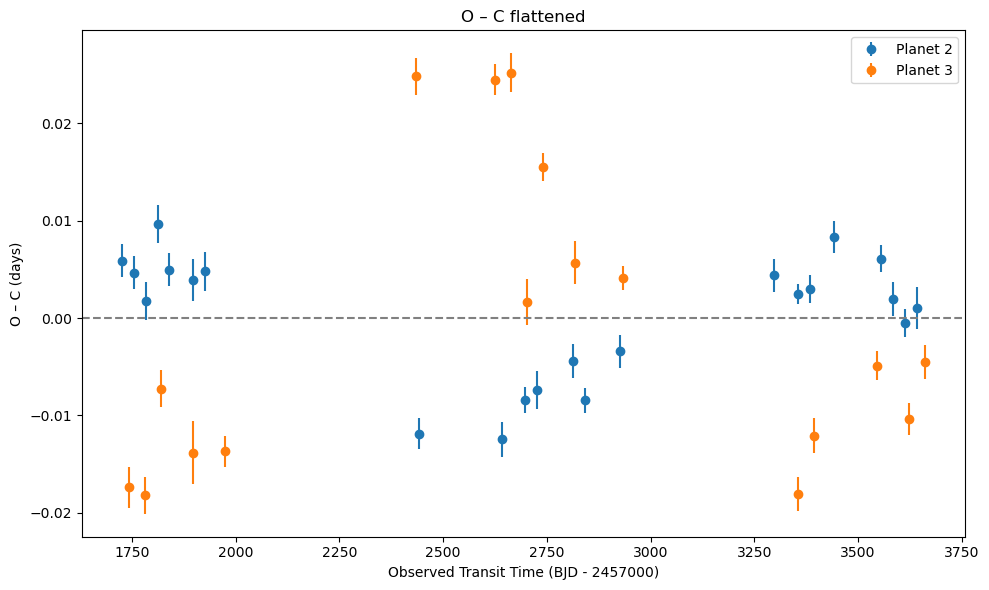

In [65]:
df_oc, ephem_df = compute_oc(df)

# Plot: O–C vs. Tc_obs for all planets
plt.figure(figsize=(10, 6))
for planet in df_oc['Planet_num'].unique():
    subset = df_oc[df_oc['Planet_num'] == planet]
    plt.errorbar(
        subset['Tc'], subset['O-C'], yerr=subset['Tc_err'],
        fmt='o', label=f'Planet {planet}'
    )

plt.axhline(0, color='gray', linestyle='--')
plt.xlabel(f"Observed Transit Time (BJD - {tess_offset})")
plt.ylabel("O – C (days)")
plt.title("O – C flattened")
plt.legend()
plt.tight_layout()
plt.show()

# Single Harmonic Sine Fit

In [66]:
### from Lithwick et al. 2012
### TTV period 
def ttv_per(P2, j, delta):
    P12 = P2 / (j*np.abs(delta))
    return P12

def delta_(P1, P2, j):
    d = ((P2/P1)*((j-1)/j)) - 1
    return d


In [67]:
print(ephem_df)


   Planet_num           T0    T0_err     Period  Period_err
0           2  1726.049086  0.000661  28.580319    0.000015
1           3  1743.570206  0.000830  38.351230    0.000026


In [68]:
j = 4 # 4:3 MMR
p_2 = ephem_df['Period'][0]
p_3 = ephem_df['Period'][1]
tc_2 = ephem_df['T0'][0]
tc_3 = ephem_df['T0'][1]


delta = delta_(p_2, p_3, j)
print(f'delta: {delta}')

ttv_period = ttv_per(p_3, j, delta)
print(f'TTV period: {ttv_period} days')

delta: 0.006406625221686113
TTV period: 1496.5457284396286 days


In [69]:
def ttv_amp_1(P1, m2, m_star, j, delta, f, Z):
    term1_num = m2/m_star
    term1_den = np.pi * j**(2./3.) * (j-1)**(1./3.) * delta
    term1 = term1_num / term1_den
    term2 = -f - ((3*Z)/(2*delta))
    ttv_amp = P1 * term1 * term2
    return ttv_amp

def ttv_amp_2(P2, m1, m_star, j, delta, g, Z):
    term1_num = m1/m_star
    term1_den = np.pi * j * delta
    term1 = term1_num / term1_den
    term2 = -g - ((3*Z)/2*delta)
    ttv_amp = P2 * term1 * term2
    return ttv_amp

In [70]:
def model_b(i_b, t_b0, P_b, A_bc, P_cb, t_cb0):
    t_linear = t_b0 + P_b * i_b
    return t_linear + A_bc * np.sin((2 * np.pi / P_cb) * (t_linear - t_cb0))


def model_c(i_c, t_c0, P_c, A_cb, P_cb, t_cb0):
    t_linear = t_c0 + P_c * i_c
    return t_linear + A_cb * np.sin((2 * np.pi / P_cb) * (t_linear - t_cb0))


def residuals(params, i_b, t_obs_b, err_b, i_c, t_obs_c, err_c):
    t_b0, P_b, A_bc, t_c0, P_c, A_cb, P_cb, t_cb0 = params

    ### define models
    t_model_b = model_b(i_b, t_b0, P_b, A_bc, P_cb, t_cb0)
    t_model_c = model_c(i_c, t_c0, P_c, A_cb, P_cb, t_cb0)

    ### find residuals
    res_b = (t_obs_b - t_model_b) / err_b
    res_c = (t_obs_c - t_model_c) / err_c

    return np.concatenate([res_b, res_c])


In [71]:
# Initial guesses for parameters
initial_t_b0 = tc_2
initial_P_b = p_2
initial_A_bc = .012    ####
initial_t_c0 = tc_3
initial_P_c = p_3
initial_A_cb =  0.2   ####
initial_P_cb = ttv_period
initial_t_cb0 = tc_3   ###

initial_params = [initial_t_b0, initial_P_b, initial_A_bc, initial_t_c0, 
                  initial_P_c, initial_A_cb, initial_P_cb, initial_t_cb0]


In [72]:
from scipy.optimize import least_squares

indices_2 = np.array(indices_2)
transit_times_2 = np.array(transit_times_2)
tc_err_2 = np.array(tc_err_2)

indices_3 = np.array(indices_3)
transit_times_3 = np.array(transit_times_3)
tc_err_3 = np.array(tc_err_3)


### Run the fit (fitting residuals)
result = least_squares(
    residuals,
    initial_params,
    args=(indices_2, transit_times_2, tc_err_2, indices_3, transit_times_3, tc_err_3),
    method='trf'
)

fitted_params = result.x
print(fitted_params)

### unpack fit params
t_b0, P_b, A_bc, t_c0, P_c, A_cb, P_cb, t_cb0 = fitted_params

[ 1.72604644e+03  2.85803091e+01  8.19916304e-03  1.74357256e+03
  3.83512495e+01 -1.88287823e-02  1.61777916e+03  1.32427206e+03]


In [73]:
from numpy.linalg import inv
### errors on fit 
J = result.jac
cov = inv(J.T @ J)
param_errors = np.sqrt(np.diag(cov))
t_b0_err, P_b_err, A_bc_err, t_c0_err, P_c_err, A_cb_err, P_cb_err, t_cb0_err = param_errors

In [74]:
# Names of parameters in order
param_names = ["t_b0", "P_b", "A_bc", "t_c0", "P_c", "A_cb", "P_cb", "t_cb0"]

print("Fitted Parameters with 1σ Uncertainties:\n")
for name, val, err in zip(param_names, fitted_params, param_errors):
    print(f"{name:>6} = {val:.8f} ± {err:.8f}")


Fitted Parameters with 1σ Uncertainties:

  t_b0 = 1726.04644084 ± 0.00073120
   P_b = 28.58030913 ± 0.00001706
  A_bc = 0.00819916 ± 0.00049904
  t_c0 = 1743.57256141 ± 0.00118624
   P_c = 38.35124954 ± 0.00004370
  A_cb = -0.01882878 ± 0.00070430
  P_cb = 1617.77915614 ± 42.37760769
 t_cb0 = 1324.27205738 ± 44.33405182


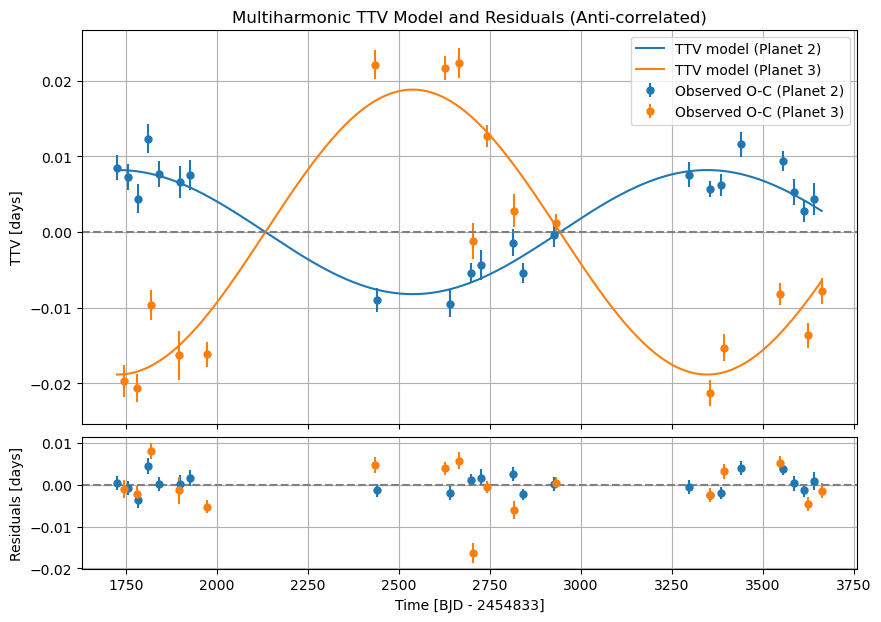

In [75]:
from matplotlib.gridspec import GridSpec
# Combine observed times to set the time range
all_times = np.concatenate([transit_times_2, transit_times_3])
t_dense = np.linspace(np.min(all_times), np.max(all_times), 1000)

# Compute "virtual" transit indices for continuous times
i_dense_b = (t_dense - t_b0) / P_b
i_dense_c = (t_dense - t_c0) / P_c

# Linear ephemerides
t_lin_b = t_b0 + P_b * i_dense_b
t_lin_c = t_c0 + P_c * i_dense_c

# Anti-correlated TTV signals: negate one amplitude!
ttv_b = A_bc * np.sin((2 * np.pi / P_cb) * (t_lin_b - t_cb0)) #* 1440
ttv_c = A_cb * np.sin((2 * np.pi / P_cb) * (t_lin_c - t_cb0)) #* 1440  

# Observed linear ephemerides
t_lin_obs_b = t_b0 + P_b * np.array(indices_2)
t_lin_obs_c = t_c0 + P_c * np.array(indices_3)

# Observed O-C residuals in minutes
oc_b = (np.array(transit_times_2) - t_lin_obs_b) #* 1440
oc_c = (np.array(transit_times_3) - t_lin_obs_c) #* 1440


# Predict TTV model at observed times (for residuals)
ttv_model_b = A_bc * np.sin((2 * np.pi / P_cb) * (t_lin_obs_b - t_cb0)) #* 1440
ttv_model_c = A_cb * np.sin((2 * np.pi / P_cb) * (t_lin_obs_c - t_cb0)) #* 1440

# Residuals: (observed O-C) - (model TTV)
residuals_b = oc_b - ttv_model_b
residuals_c = oc_c - ttv_model_c

# Plot with subpanels: main TTV + residuals
fig = plt.figure(figsize=(10, 7))
gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0.05)

# TTV Model and Observations
ax1 = fig.add_subplot(gs[0])

ax1.plot(t_dense, ttv_b, label="TTV model (Planet 2)", color='tab:blue')
ax1.plot(t_dense, ttv_c, label="TTV model (Planet 3)", color='tab:orange')

ax1.errorbar(t_lin_obs_b, oc_b, yerr=np.array(tc_err_2), fmt='o',
             color='tab:blue', label='Observed O-C (Planet 2)', markersize=5)
ax1.errorbar(t_lin_obs_c, oc_c, yerr=np.array(tc_err_3), fmt='o',
             color='tab:orange', label='Observed O-C (Planet 3)', markersize=5)

ax1.axhline(0, color='gray', linestyle='--')
ax1.set_ylabel("TTV [days]")
ax1.set_title("Multiharmonic TTV Model and Residuals (Anti-correlated)")
ax1.tick_params(labelbottom=False) 
ax1.legend()
ax1.grid(True)

# Residuals Panel
ax2 = fig.add_subplot(gs[1], sharex=ax1)

ax2.errorbar(t_lin_obs_b, residuals_b, yerr=np.array(tc_err_2), fmt='o',
             color='tab:blue', markersize=5, label="Residuals (b)")
ax2.errorbar(t_lin_obs_c, residuals_c, yerr=np.array(tc_err_3), fmt='o',
             color='tab:orange', markersize=5, label="Residuals (c)")

ax2.axhline(0, color='gray', linestyle='--')
ax2.set_xlabel("Time [BJD - 2454833]")
ax2.set_ylabel("Residuals [days]")
ax2.grid(True)

plt.show()

In [76]:
print('Predicted values from Lubin et al 2022:')
print('predicted P_23: 1490 ± 10 days')
print('predicted A_23: 15.5 ± 9.1 min')
print('predicted A_32: 59.2 ± 13.8 min')
print('Multi-harmonic fit values:')
print(f'P_23: {np.round(P_cb,6)} ± {np.round(P_cb_err,6)} days')
print(f'A_23: {np.round(A_bc,6)*1440} ± {np.round(A_bc_err,6)*1440} min')
print(f'A_32: {np.round(A_cb,6)*1440} ± {np.round(A_cb_err,6)*1440} min')

Predicted values from Lubin et al 2022:
predicted P_23: 1490 ± 10 days
predicted A_23: 15.5 ± 9.1 min
predicted A_32: 59.2 ± 13.8 min
Multi-harmonic fit values:
P_23: 1617.779156 ± 42.377608 days
A_23: 11.80656 ± 0.71856 min
A_32: -27.11376 ± 1.01376 min


# Save Data

In [77]:
import pickle

# Bundle all relevant data into a dictionary
ttv_data = {
    "tc_lin_obs_2": t_lin_obs_b,
    "tc_lin_obs_3": t_lin_obs_c,
    "omc_2": oc_b,
    "omc_3": oc_c,
    "ttv_model_2": ttv_model_b,
    "ttv_model_3": ttv_model_c,
    "residuals_2": residuals_b,
    "residuals_3": residuals_c,
    "tc_err_2": np.array(tc_err_2),
    "tc_err_3": np.array(tc_err_3),
    "indices_2": np.array(indices_2),
    "indices_3": np.array(indices_3),
    "t_dense": np.array(t_dense),
    "ttv_2": np.array(ttv_b),
    "ttv_3": np.array(ttv_c)
}

# Save to a file
with open("1339_sine_fit.pkl", "wb") as f:
    pickle.dump(ttv_data, f)
